c:\Users\Jana\anaconda3\ana\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



 Tree 1:
DecisionTreeClassifier(max_depth=1, random_state=1608637542)

 Tree 2:
DecisionTreeClassifier(max_depth=1, random_state=1273642419)

 Tree 3:
DecisionTreeClassifier(max_depth=1, random_state=1935803228)

 Tree 4:
DecisionTreeClassifier(max_depth=1, random_state=787846414)

 Tree 5:
DecisionTreeClassifier(max_depth=1, random_state=996406378)

 Tree 6:
DecisionTreeClassifier(max_depth=1, random_state=1201263687)

 Tree 7:
DecisionTreeClassifier(max_depth=1, random_state=423734972)

 Tree 8:
DecisionTreeClassifier(max_depth=1, random_state=415968276)

 Tree 9:
DecisionTreeClassifier(max_depth=1, random_state=670094950)

 Tree 10:
DecisionTreeClassifier(max_depth=1, random_state=1914837113)


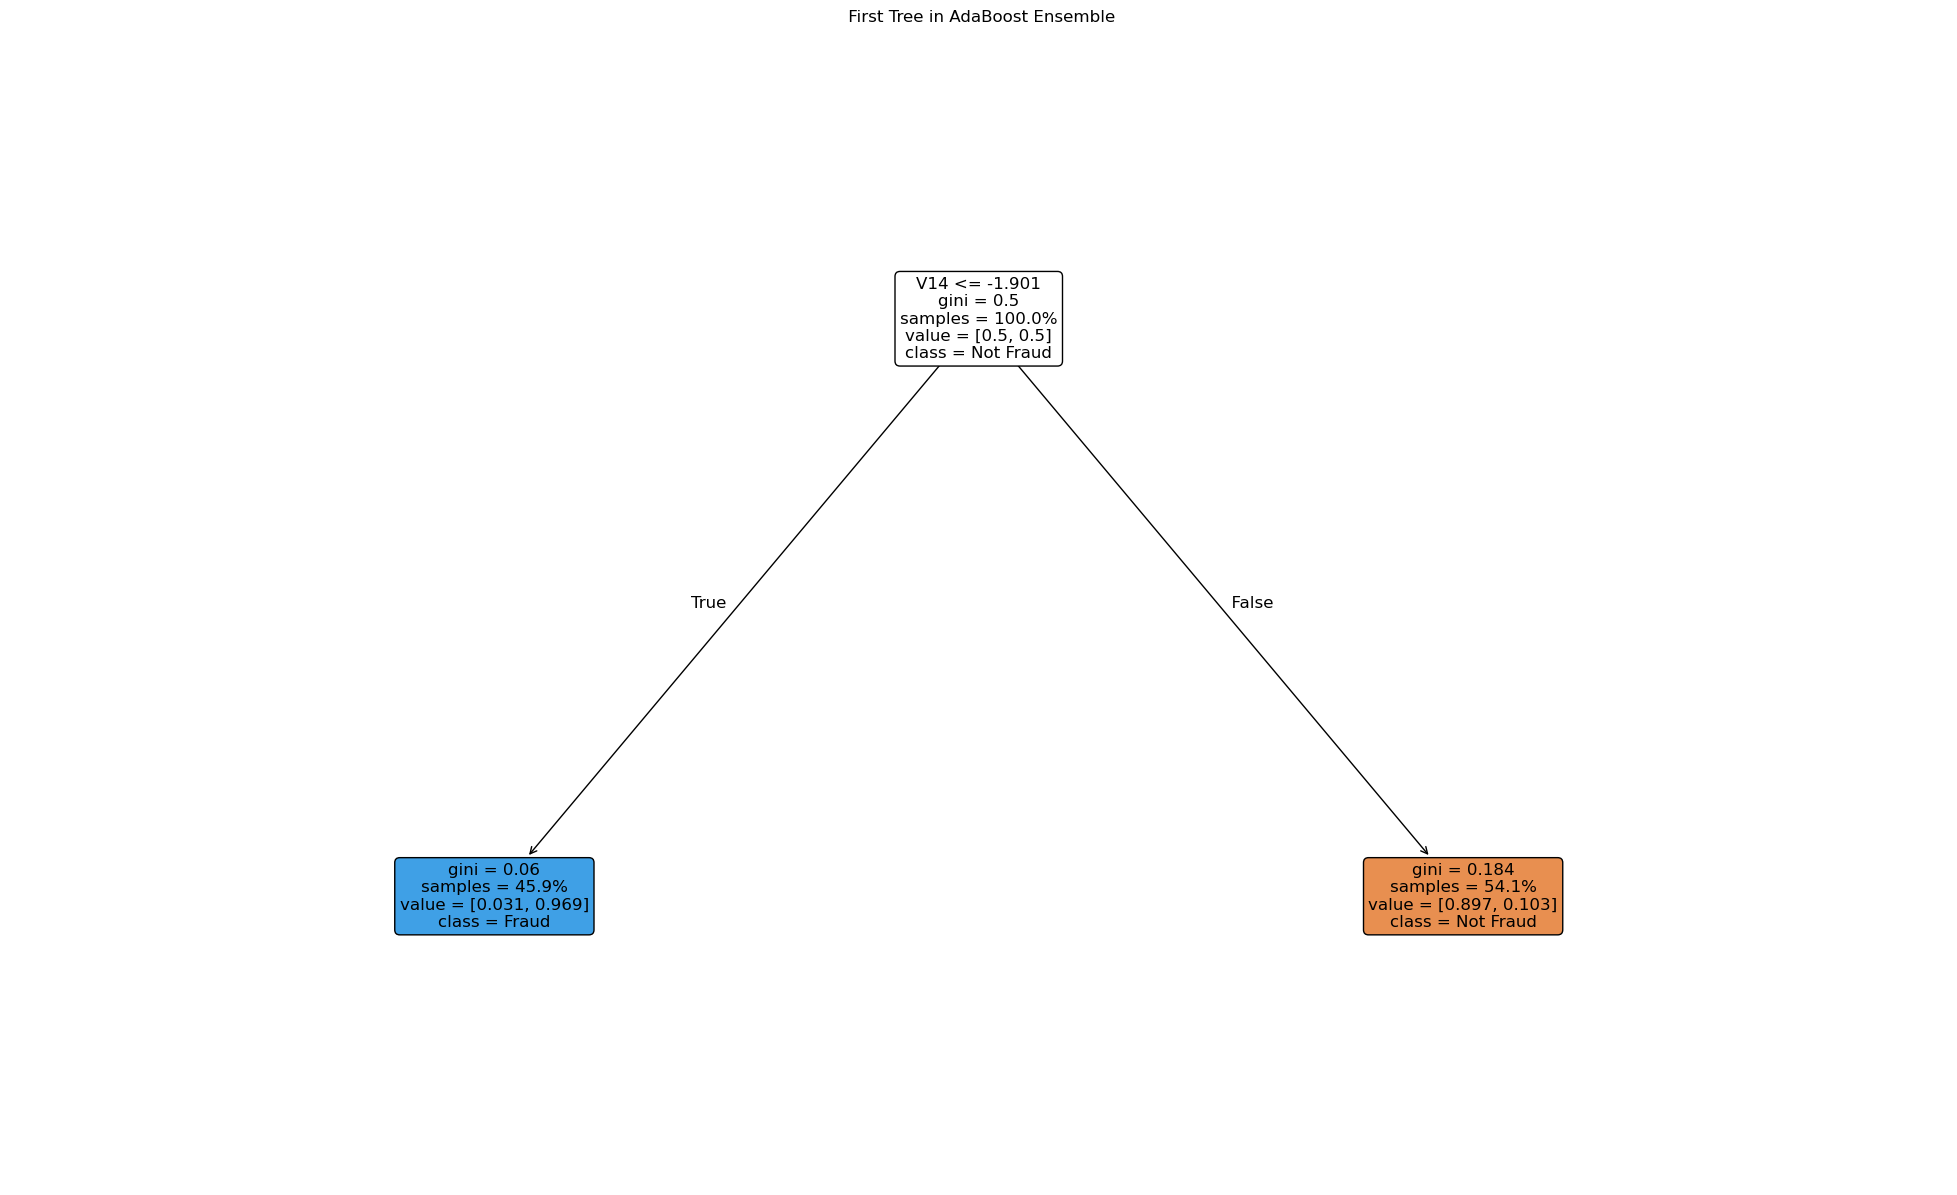


 Model Performance Metrics:
   Metric    Score
 Accuracy 0.972157
Precision 0.052188
   Recall 0.878378
 F1-Score 0.098522
  ROC AUC 0.952147

 Confusion Matrix:
[[82934  2361]
 [   18   130]]


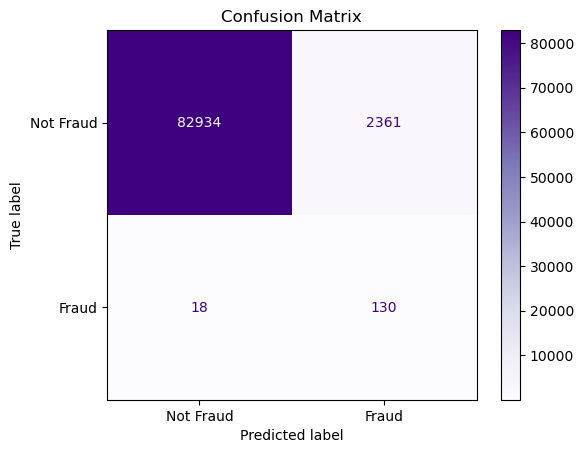

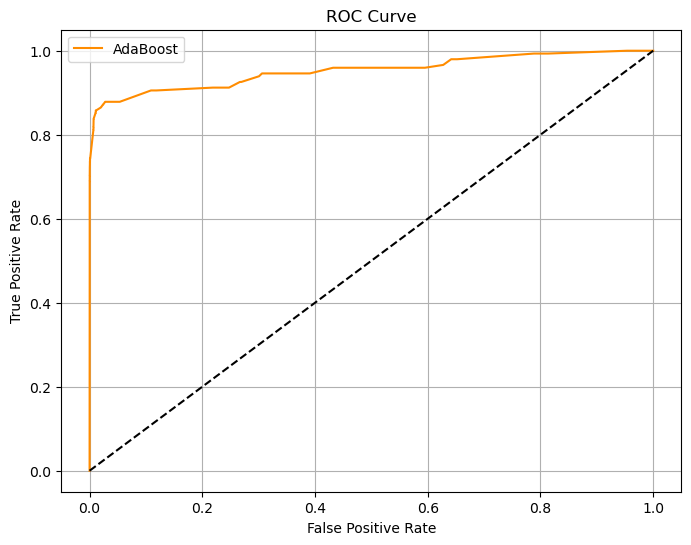

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

data = pd.read_csv("creditcard.csv")

X = data.drop('Class', axis=1)
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=10,  
    learning_rate=1.0,
    random_state=42
)

ada.fit(X_train_resampled, y_train_resampled)


for idx, tree_model in enumerate(ada.estimators_):
    print(f"\n Tree {idx + 1}:")
    print(tree_model)


from sklearn import tree
import matplotlib.pyplot as plt


first_tree = ada.estimators_[0]

plt.figure(figsize=(25,15)) 
tree.plot_tree(
    first_tree,
    filled=True,
    rounded=True, 
    feature_names=data.drop('Class', axis=1).columns,
    class_names=["Not Fraud", "Fraud"],
    proportion=True, 
    fontsize=12  
)
plt.title(" First Tree in AdaBoost Ensemble")
plt.show()

y_pred = ada.predict(X_test)
y_probs = ada.predict_proba(X_test)[:, 1]

metrics_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC'],
    'Score': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_probs)
    ]
})

print("\n Model Performance Metrics:")
print(metrics_table.to_string(index=False))


print("\n Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(
    ada, X_test, y_test,
    display_labels=["Not Fraud", "Fraud"],
    cmap="Purples"
)
plt.title("Confusion Matrix")
plt.show()


fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label="AdaBoost", color='darkorange')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()
